# 1. Environment Setup & Data Loading

# Loading data in colab
Bad data loading pattern: just mounting your google drive, then having your pytorch dataloader load files from that drive during training. This is slow since each load goes over the network

Better dataloading pattern: copy all your files over from /content/drive/ to something like /content/local_wavfiles

Best dataloading pattern: copy a single .zip with your files over to /content/wavfiles.zip. Unzip on VM to /content/local_wavfiles

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# Run this ONCE to create the zip file in your Drive
#!zip -r -q /content/drive/MyDrive/bird_classification_data/wavfiles.zip /content/drive/MyDrive/bird_classification_data/wavfiles/

In [3]:
import os
import shutil

local_dir = "/content/local_wavfiles/"
drive_zip = "/content/drive/MyDrive/bird_classification_data/wavfiles.zip"
local_zip = "/content/wavfiles.zip"

# 1. Remove the incomplete directory if it exists to force a fresh extraction
if os.path.exists(local_dir):
    print("Found existing incomplete folder. Cleaning it up...")
    shutil.rmtree(local_dir)

# Create the fresh directory
os.makedirs(local_dir, exist_ok=True)

print("Copying zip from Drive (Fast!)...")
os.system(f"cp {drive_zip} {local_zip}")

print("Copy complete! Unzipping (this may take a minute)...")
# 2. Unzip quietly (-q) and "junk" paths (-j) to avoid creating nested folders
# like /content/local_wavfiles/content/drive/MyDrive/...
os.system(f"unzip -q -j {local_zip} -d {local_dir}")

# 3. Clean up the local zip file to save Colab disk space
os.system(f"rm {local_zip}")
print("Unzip complete! All files should now be directly in", local_dir)

Copying zip from Drive (Fast!)...
Copy complete! Unzipping (this may take a minute)...
Unzip complete! All files should now be directly in /content/local_wavfiles/


# 2. Data Preprocessing & Metadata

In [4]:
import os
import torch
import torch.nn as nn
import pandas as pd
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [5]:
# Change your paths from "data\\..." to your mounted drive path
bird_df = pd.read_csv("/content/drive/MyDrive/bird_classification_data/bird_songs_metadata.csv", usecols=['filename', 'species'])
bird_df["filename"] = "/content/local_wavfiles/" + bird_df["filename"]

In [6]:
# Encode string labels to integers
label_encoder = LabelEncoder()
bird_df["label"] = label_encoder.fit_transform(bird_df["species"])

In [7]:
import soundfile as sf
from tqdm import tqdm

durations = []

# Loop over all file paths in your dataframe
for filepath in tqdm(bird_df["filename"], desc="Calculating Durations"):
    info = sf.info(filepath)
    durations.append(info.duration)

# Add durations back to your dataframe for easy querying
bird_df["duration"] = durations

# Calculate statistics
max_duration = bird_df["duration"].max()
mean_duration = bird_df["duration"].mean()

print("\n--- Audio Duration Analysis ---")
print(f"Max Duration:  {max_duration:.2f} seconds")
print(f"Mean Duration: {mean_duration:.2f} seconds")

Calculating Durations: 100%|██████████| 5422/5422 [00:00<00:00, 14121.67it/s]


--- Audio Duration Analysis ---
Max Duration:  3.00 seconds
Mean Duration: 3.00 seconds


In [8]:
train_df, test_df = train_test_split(bird_df, test_size=0.2, random_state=42, stratify=bird_df["label"])

# 3. PyTorch Dataset & DataLoaders

# 3. PyTorch Dataset & DataLoaders

### Technical Overview
Defines a custom `BirdAudioDataset` class that handles standardizing raw audio inputs into Log-Mel Spectrograms on the fly inside PyTorch's data pipeline.

### Signal Processing & PyTorch Data Loading Mechanics
1. **On-the-Fly CPU Transformations:** PyTorch performs transformations in `__getitem__` on the CPU before batching and transferring tensors to the GPU via `DataLoader`.
2. **Channel & Rate Standardization:** Stereo signals are averaged to mono (`waveform.mean(dim=0)`), and sample rates are converted via `torchaudio.transforms.Resample`.
3. **Fixed Frame Dimension Math:**
   Audio clips are trimmed or zero-padded to an exact length ($3\text{ seconds} \times 22,050\text{ Hz} = 66,150\text{ samples}$).
   The resulting time frame dimension ($130\text{ time steps}$) is governed by:
   $$\text{time_steps} = \lfloor \frac{\text{num_samples}}{\text{hop_length}} \rfloor + 1 = \lfloor \frac{66,150}{512} \rfloor + 1 = 130$$
4. **Log-Scale Dynamics:** Passing power spectrograms through `AmplitudeToDB` maps raw energy values into decibels, matching the logarithmic nature of human/animal sound perception.
5. **Dataloader Parallelism:** Setting `num_workers=2` (or higher) and `pin_memory=True` spins up asynchronous CPU processes to keep the GPU pipeline saturated with pre-extracted batches.

In [9]:
class BirdAudioDataset(Dataset):
    def __init__(self, df, target_sample_rate=22050, duration_seconds=3, n_mels=64):
        """
        df: Pandas DataFrame containing 'filename' and 'label'
        target_sample_rate: Standardize all audio sample rates
        duration_seconds: Enforce uniform length (e.g., 3-second chunks)
        n_mels: Number of frequency bins (this will act as our Transformer feature/embedding dimension)
        """
        self.df = df.reset_index(drop=True)
        self.target_sample_rate = target_sample_rate
        self.num_samples = target_sample_rate * duration_seconds

        # Audio Transformation Layer (Mel-Spectrogram)
        self.mel_transform = T.MelSpectrogram(
            sample_rate=self.target_sample_rate,
            n_fft=1024,
            hop_length=512,
            n_mels=n_mels
        )

        # Converts power to decibels (log scale) which models human/animal hearing better
        self.amplitude_to_db = T.AmplitudeToDB()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row["filename"]
        label = row["label"]

        # 1. Load Audio
        waveform, sr = torchaudio.load(path)

        # 2. Standardize Channels (Convert stereo to mono if necessary)
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)

        # 3. Resample if the file rate doesn't match our target rate
        if sr != self.target_sample_rate:
            resampler = T.Resample(sr, self.target_sample_rate)
            waveform = resampler(waveform)

        # 4. Standardize Length (Fixes DataLoader KeyError/Shape mismatch)
        if waveform.shape[1] > self.num_samples:
            # Crop
            waveform = waveform[:, :self.num_samples]
        elif waveform.shape[1] < self.num_samples:
            # Pad with zeros
            pad_amount = self.num_samples - waveform.shape[1]
            waveform = torch.nn.functional.pad(waveform, (0, pad_amount))

        # 5. Extract Mel-Spectrogram Feature
        mel_spec = self.mel_transform(waveform)
        mel_spec = self.amplitude_to_db(mel_spec) # Shape: [1, n_mels, time_steps]

        # Remove the channel dimension so the shape is [n_mels, time_steps]
        mel_spec = mel_spec.squeeze(0)

        return mel_spec, torch.tensor(label, dtype=torch.long)

The time_steps value (which is 130 in your case) is determined by three variables in your BirdAudioDataset class:

Audio Length (num_samples): You set this to 66,150 (3 seconds × 22,050 Hz).
n_fft (1024): The size of the window used for the Fourier Transform.
hop_length (512): This is the most important factor. It defines the 'stride' or the number of samples the window slides forward to create the next time frame.
The math follows this general formula: time_steps = floor(num_samples / hop_length) + 1

So, 66,150 / 512 ≈ 129.19, which results in 130 time steps. If you want more 'resolution' in time, you would decrease the hop_length; if you want a smaller model input, you would increase it.

In [10]:
# Re-run to apply the BirdAudioDataset fix (filepath -> filename)
# Create Dataset instances
train_dataset = BirdAudioDataset(train_df, target_sample_rate=22050, duration_seconds=3, n_mels=64)
test_dataset = BirdAudioDataset(test_df, target_sample_rate=22050, duration_seconds=3, n_mels=64)

# Create DataLoaders
# num_workers=2 spins up background processes to load audio efficiently while your GPU trains
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# Sanity Check Shapes
features, targets = next(iter(train_dataloader))
print(f"Batch Features Shape (Batch, n_mels, time_steps): {features.shape}")
print(f"Batch Labels Shape: {targets.shape}")


Batch Features Shape (Batch, n_mels, time_steps): torch.Size([32, 64, 130])
Batch Labels Shape: torch.Size([32])


# 4. Exploratory Data Analysis (EDA)

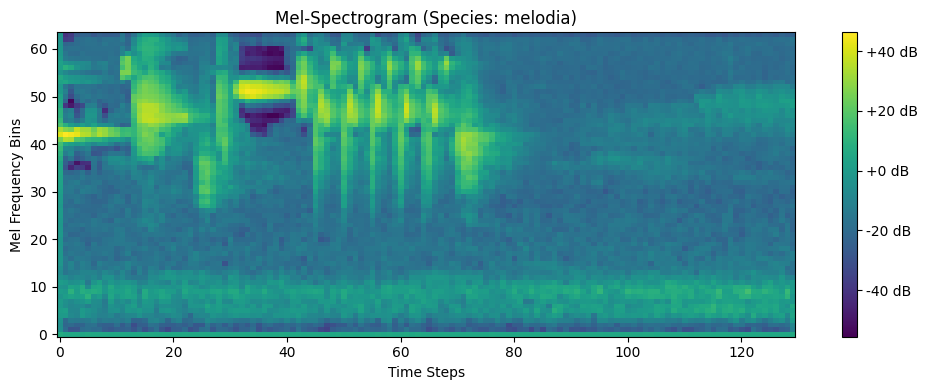

Species Label: melodia


In [11]:
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import torchaudio

# Grab a sample directly from the dataset so we can access its original file path
sample_idx = 200
sample_mel, sample_label_tensor = train_dataset[sample_idx]
sample_label = sample_label_tensor.item()

# Convert the integer label back to the string species name
species_name = label_encoder.inverse_transform([sample_label])[0]

# Get the file path from the dataframe to load the raw audio for playback
audio_path = train_dataset.df.iloc[sample_idx]["filename"]
waveform, sr = torchaudio.load(audio_path)

plt.figure(figsize=(10, 4))
# Plot the 2D tensor. origin='lower' puts the low frequencies at the bottom.
plt.imshow(sample_mel.numpy(), aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(format='%+2.0f dB')
plt.title(f'Mel-Spectrogram (Species: {species_name})')
plt.xlabel('Time Steps')
plt.ylabel('Mel Frequency Bins')
plt.tight_layout()
plt.show()

# Play the audio and print the string label
print(f"Species Label: {species_name}")
display(Audio(data=waveform.numpy(), rate=sr))


In [12]:
sample_mel.shape

torch.Size([64, 130])

# 5. Custom CNN Model

### Technical Overview
Implements a baseline 2D Convolutional Neural Network (`BirdAudioClassifier`) with `nn.Conv2d`, `nn.MaxPool2d`, and `nn.LazyLinear` layers.

### Architectural Insights & Inductive Biases
* **2D Convolutions for Audio:** Treats the Log-Mel Spectrogram as a 1-channel grayscale image ($Y\text{-axis} = \text{Frequency}$, $X\text{-axis} = \text{Time}$).
* **Spatial Locality (Inductive Bias):** CNNs are highly effective on lightweight spectrograms ($64 \times 130$) because 2D filters naturally extract local features like time-frequency edges and harmonic stacks without requiring millions of parameters.
* **`nn.LazyLinear`:** Automatically infers flattened feature map dimensions ($6 \text{ channels} \times 16 \text{ frequency bins} \times 32 \text{ time frames} = 3072$), preventing manual shape calculation errors.

In [13]:
class BirdAudioClassifier(nn.Module):
    def __init__(self, hidden_dim, num_classes):
        super(BirdAudioClassifier, self).__init__()

        self.main = nn.Sequential(
            # Input: [Batch, 1, 64, 130]
            # Layer 1: 6 filters, each looking at 1 input channel
            nn.Conv2d(1, 10, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Shape now: [Batch, 6, 32, 65]

            # Layer 2: 6 filters, each looking at ALL 6 input channels
            # Total filters used here = 6 (the out_channels value)
            nn.Conv2d(10, 10, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Shape now: [Batch, 6, 16, 32]

            nn.Flatten(),
            # LazyLinear calculates: 6 channels * 16 * 32 = 3072 inputs
            nn.LazyLinear(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        if x.dim() == 3:
            x = x.unsqueeze(1)
        return self.main(x)

In [14]:
# Note: input_dim is no longer needed thanks to LazyLinear
cnn = BirdAudioClassifier(hidden_dim=64, num_classes=len(label_encoder.classes_))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn.to(device) # Ensure model is on the same device as data

BirdAudioClassifier(
  (main): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): LazyLinear(in_features=0, out_features=64, bias=True)
    (8): ReLU()
    (9): Linear(in_features=64, out_features=5, bias=True)
  )
)

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=0.001)

In [16]:
def evaluate_model(model, dataloader, criterion, device):
    # 1. Set the model to evaluation mode
    cnn.eval()

    test_loss = 0.0
    correct = 0
    total = 0

    # 2. Disable gradient tracking
    with torch.no_grad():
        for batch, labels in dataloader:
            # Move data to the same device as the model
            batch, labels = batch.to(device), labels.to(device)

            # Forward pass
            outputs = model(batch)

            # Calculate loss
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            # Get predictions (the class with the highest logit/probability)
            _, predicted = torch.max(outputs.data, 1)

            # Tally up the totals and correct predictions
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Calculate final metrics
    avg_loss = test_loss / len(dataloader)
    accuracy = 100 * correct / total

    print(f"Test Loss: {avg_loss:.4f}")
    print(f"Test Accuracy: {accuracy:.2f}% ({correct}/{total} correct)")

    return avg_loss, accuracy

# Run the evaluation
# evaluate_model(cnn, test_dataloader, criterion, device)


In [17]:
def train_model(model, train_dataloader, test_dataloader, criterion, optimizer, device, epochs=5):
    # Use GPU if available, otherwise fallback to CPU
    print(f"Using device: {device}")

    for epoch in range(epochs):
        model.train()
        batch_num = 1
        correct = 0
        total = 0
        # This 'on-the-fly' transfer is the standard practice
        for batch, labels in train_dataloader:
            # Moving only the current batch to the device (GPU)
            batch, labels = batch.to(device), labels.to(device)

            out = model(batch)
            loss = criterion(out, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Track training accuracy
            _, predicted = torch.max(out.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # print(f"Loss: {loss.item()}")
            # print(f"Percent finished with epoch:", batch_num * train_dataloader.batch_size / len(train_dataloader.dataset))
            batch_num += 1

        train_accuracy = 100 * correct / total
        print(f"Epoch {epoch+1} complete. Training Accuracy: {train_accuracy:.2f}%")
        evaluate_model(model, test_dataloader, criterion, device)

# You can now train the CNN by calling:
# train_model(cnn, train_dataloader, test_dataloader, criterion, optimizer, device, epochs=5)


In [18]:
train_model(cnn, train_dataloader, test_dataloader, criterion, optimizer, device)

Using device: cuda
Epoch 1 complete. Training Accuracy: 56.01%
Test Loss: 0.7388
Test Accuracy: 71.06% (771/1085 correct)
Epoch 2 complete. Training Accuracy: 76.11%
Test Loss: 0.6125
Test Accuracy: 74.56% (809/1085 correct)
Epoch 3 complete. Training Accuracy: 82.98%
Test Loss: 0.5428
Test Accuracy: 78.16% (848/1085 correct)
Epoch 4 complete. Training Accuracy: 89.02%
Test Loss: 0.5381
Test Accuracy: 79.35% (861/1085 correct)
Epoch 5 complete. Training Accuracy: 93.18%
Test Loss: 0.5211
Test Accuracy: 81.01% (879/1085 correct)


# 6. Custom Transformer Model

### Technical Overview
Builds a Vision-Transformer-style architecture (`TransformerEncoderClassifier`) from scratch using PyTorch `nn.TransformerEncoderLayer`.

### Architectural Mechanics & Patch Slicing
1. **Patch Projection via Conv2d:** Instead of manual tensor slicing, a non-overlapping `Conv2d` layer with `kernel_size = stride = (16, 10)` divides the $[64 \times 130]$ spectrogram into a grid of 52 distinct patches ($4 \text{ vertical} \times 13 \text{ horizontal}$).
2. **Patch Embeddings:** The `Conv2d` projects each patch into a $d\_model$ ($128$) dimensional vector embedding.
3. **`[CLS]` Token & 2D Positional Embeddings:** A learnable `[CLS]` token is prepended to the patch sequence, and a trainable 2D positional embedding matrix is added to preserve time and frequency spatial layouts.
4. **Self-Attention Trade-Offs:** Unlike CNNs, Vision Transformers have **no built-in spatial bias**. They require learning time-frequency relationships from scratch via global self-attention, which often demands larger datasets or longer training schedules to match CNN performance.

In [19]:
import torch
import torch.nn as nn

class TransformerEncoderClassifier(nn.Module):
    def __init__(self, num_classes, d_model=128, nhead=4, num_layers=3):
        super(TransformerEncoderClassifier, self).__init__()

        # Patch dimensions matching your grid
        self.patch_height = 16 # Frequency
        self.patch_width = 10  # Time
        self.num_patches = (64 // 16) * (130 // 10) # 4 * 13 = 52

        # 1. Conv2d with kernel=stride acts as patch slicing + linear projection
        # This conv2d isn't a typical conv layer for extracting visual features
        # instead, it creates d_model feature maps, each with 52 patches
        # Now, each of the 52 patches can be represented as an embedding of size d_model
        self.patch_embed = nn.Conv2d(
            in_channels=1,
            out_channels=d_model,
            kernel_size=(self.patch_height, self.patch_width),
            stride=(self.patch_height, self.patch_width)
        )

        # 2. Trainable [CLS] token and Positional Embedding
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embedding = nn.Parameter(torch.randn(1, self.num_patches + 1, d_model)) # self.num_patches + 1 for [CLS]

        # 3. Standard Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            # temporarily expands embedding dimension after self-attention, then projects back down to d_model
            dim_feedforward=d_model * 2,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # 4. Classification Head
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # Ensure 4D shape: [Batch, 1, 64, 130]
        if x.dim() == 3:
            x = x.unsqueeze(1)

        B = x.size(0)

        # Extract & flatten patches: [B, 1, 64, 130] -> [B, d_model, 4, 13] -> [B, 52, d_model]
        x = self.patch_embed(x)
        x = x.flatten(2).transpose(1, 2)

        # Expand [CLS] token across batch and prepend: [B, 53, d_model]
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        # Add 2D Positional Embeddings
        x = x + self.pos_embedding

        # Pass through Transformer
        x = self.transformer(x)

        # Extract [CLS] token output (index 0) and classify
        # all batches, first token ([CLS]), every dim of d_model
        cls_out = x[:, 0, :]
        logits = self.classifier(cls_out)

        return logits

In [20]:
# Note: input_dim is no longer needed thanks to LazyLinear
transformer_encoder = TransformerEncoderClassifier(num_classes=len(label_encoder.classes_))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transformer_encoder.to(device) # Ensure model is on the same device as data

TransformerEncoderClassifier(
  (patch_embed): Conv2d(1, 128, kernel_size=(16, 10), stride=(16, 10))
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classifier): Linear(in_features=128, out_features=5, bias=True)
)

In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(transformer_encoder.parameters(), lr=0.001)
train_model(transformer_encoder, train_dataloader, test_dataloader, criterion, optimizer, device, epochs=50)

Using device: cuda
Epoch 1 complete. Training Accuracy: 42.33%
Test Loss: 1.1664
Test Accuracy: 49.03% (532/1085 correct)
Epoch 2 complete. Training Accuracy: 53.19%


KeyboardInterrupt: 

# 7. Audio Spectrogram Transformer (AST) Fine-Tuning

### Technical Overview
Fine-tunes a pre-trained Audio Spectrogram Transformer (`MIT/ast-finetuned-audioset-10-10-0.4593`) using Hugging Face `transformers`.

### Key Challenges & Optimizations

* **The Hugging Face AST Pipeline:** AST expects a $16\text{ kHz}$ input and outputs an $[128 \times 1024]$ spectrogram by default (designed for 10-second AudioSet clips).
* **Positional Embedding Interpolation:** By default, AST uses a fixed position embedding matrix matching 1,214 sequence tokens ($10\text{ seconds}$). Passing shorter $3\text{ second}$ clips ($300\text{ frames} \rightarrow 234\text{ tokens}$) causes a tensor dimension mismatch (`350 vs 1214`).
  To fix this without wasting computation on zero-padding, we use **1D linear interpolation (`F.interpolate`)** to downsample the pre-trained positional embedding matrix from 1,212 patch tokens to 232 patch tokens. This cuts training memory/time by ~70% while preserving pre-trained spatial information.
* **Pre-trained Parameter Scale:** AST contains **~85 million parameters** across 12 full Transformer layers. For smaller datasets (~4,000 clips), it requires careful regularization and low learning rates (`1e-4` with `AdamW`) to avoid overfitting.
* Ultimately, I never ran this AST model for long because a single epoch took over an hour on an L4 GPU. The conclusion is that an AST is simply too bulky for a small dataset of 3-second clips. With ~85 million parameters, AST brings massive computational overhead without the built-in 2D spatial bias of a CNN. It requires processing heavy global self-attention over large token sequences, creating severe CPU feature-extraction and GPU memory bottlenecks for marginal gain on short audio clips. This is what ultimately motivated the switch to Efficient Net...

In [ ]:
import torch
import torch.nn.functional as F
from transformers import ASTForAudioClassification, ASTFeatureExtractor

def load_ast_for_custom_length(model_name, num_classes, target_max_length=300):
    # 1. Load feature extractor set to 3 seconds (300 frames)
    feature_extractor = ASTFeatureExtractor.from_pretrained(
        model_name,
        max_length=target_max_length
    )

    # 2. Load model
    model = ASTForAudioClassification.from_pretrained(
        model_name,
        num_labels=num_classes,
        ignore_mismatched_sizes=True
    )

    # Calculate target patch sequence count
    # AST patches: (128 mel bins / 16) * ((300 frames - 16) / 10 + 1) = 8 * 29 = 232 patches
    # Plus 2 special tokens ([CLS] and distillation) = 234 tokens
    # We dynamically calculate this from the patch projection layer:
    test_input = torch.zeros(1, target_max_length, 128)
    with torch.no_grad():
        patch_embeds = model.audio_spectrogram_transformer.embeddings.patch_embeddings(test_input)
        num_patches = patch_embeds.shape[1]
    target_tokens = num_patches + 2  # +2 for CLS & Distillation tokens

    # 3. Interpolate pre-trained position embeddings
    old_pos_embed = model.audio_spectrogram_transformer.embeddings.position_embeddings # [1, 1214, 768]
    cls_dist_embed = old_pos_embed[:, :2, :] # Preserve CLS and Distillation tokens
    patch_pos_embed = old_pos_embed[:, 2:, :] # [1, 1212, 768]

    # Reshape to (1, channels, length) for 1D interpolation
    patch_pos_embed = patch_pos_embed.permute(0, 2, 1) # [1, 768, 1212]
    new_patch_pos_embed = F.interpolate(
        patch_pos_embed,
        size=num_patches,
        mode='linear',
        align_corners=False
    )
    new_patch_pos_embed = new_patch_pos_embed.permute(0, 2, 1) # [1, num_patches, 768]

    # Recombine CLS/Distillation with resized patch embeddings
    new_pos_embed = torch.cat([cls_dist_embed, new_patch_pos_embed], dim=1)

    # Assign back to model as a trainable parameter
    model.audio_spectrogram_transformer.embeddings.position_embeddings = torch.nn.Parameter(new_pos_embed)

    return model, feature_extractor

In [ ]:
# Initialize AST adapted for 3-second clips (300 frames)
ast_model, feature_extractor = load_ast_for_custom_length(
    "MIT/ast-finetuned-audioset-10-10-0.4593",
    num_classes=len(label_encoder.classes_),
    target_max_length=300
)

ast_model.to(device)

In [ ]:
class ASTBirdDataset(Dataset):
    def __init__(self, df, feature_extractor, target_sample_rate=16000, duration_seconds=3):
        self.df = df.reset_index(drop=True)
        self.feature_extractor = feature_extractor
        self.target_sample_rate = target_sample_rate
        self.num_samples = target_sample_rate * duration_seconds

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        waveform, sr = torchaudio.load(row["filename"])

        # Mono conversion
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)

        # Resample to 16kHz for AST
        if sr != self.target_sample_rate:
            resampler = T.Resample(sr, self.target_sample_rate)
            waveform = resampler(waveform)

        # Pad or Crop raw audio to 3 seconds (48,000 samples)
        if waveform.shape[1] > self.num_samples:
            waveform = waveform[:, :self.num_samples]
        elif waveform.shape[1] < self.num_samples:
            waveform = torch.nn.functional.pad(waveform, (0, self.num_samples - waveform.shape[1]))

        # Extract features (explicitly enforcing 300 frames max_length)
        inputs = self.feature_extractor(
            waveform.squeeze(0).numpy(),
            sampling_rate=self.target_sample_rate,
            max_length=300,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        # Remove batch dimension -> Shape: [300, 128]
        input_values = inputs.input_values.squeeze(0)

        return input_values, torch.tensor(row["label"], dtype=torch.long)

In [ ]:
def train_ast_model(model, train_dataloader, test_dataloader, criterion, optimizer, device, epochs=10):
    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0
        batch_num = 1

        for batch, labels in train_dataloader:
            batch, labels = batch.to(device), labels.to(device)

            # AST outputs an object containing .logits
            outputs = model(batch)
            logits = outputs.logits

            loss = criterion(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            print(f"Loss: {loss.item()}")
            print(f"Percent finished with epoch:", batch_num * train_dataloader.batch_size / len(train_dataloader.dataset))
            print(f"Accuracy")
            batch_num += 1

        train_acc = 100 * correct / total
        print(f"Epoch {epoch+1} complete. Training Accuracy: {train_acc:.2f}%")

        # Validation
        model.eval()
        val_correct, val_total, val_loss = 0, 0, 0.0
        with torch.no_grad():
            for batch, labels in test_dataloader:
                batch, labels = batch.to(device), labels.to(device)
                outputs = model(batch)
                logits = outputs.logits
                loss = criterion(logits, labels)
                val_loss += loss.item()
                _, predicted = torch.max(logits.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        print(f"Test Loss: {val_loss/len(test_dataloader):.4f} | Test Accuracy: {100*val_correct/val_total:.2f}%\n")

In [93]:
# Instantiate AST Datasets & Loaders
ast_train_ds = ASTBirdDataset(train_df, feature_extractor)
ast_test_ds = ASTBirdDataset(test_df, feature_extractor)

ast_train_loader = DataLoader(ast_train_ds, batch_size=16, shuffle=True, pin_memory=True, num_workers=4)
ast_test_loader = DataLoader(ast_test_ds, batch_size=16, shuffle=False, pin_memory=True, num_workers=4)

# Optimizer with a small Learning Rate for Fine-Tuning
optimizer = torch.optim.AdamW(ast_model.parameters(), lr=1e-4, weight_decay=1e-2)

# Run Fine-Tuning
train_ast_model(ast_model, ast_train_loader, ast_test_loader, criterion, optimizer, device, epochs=10)

Loss: 1.5664353370666504
Percent finished with epoch: 0.0036891860733225734
Loss: 1.7855970859527588
Percent finished with epoch: 0.007378372146645147
Loss: 1.7741481065750122
Percent finished with epoch: 0.01106755821996772
Loss: 2.572831153869629
Percent finished with epoch: 0.014756744293290294
Loss: 2.2930691242218018
Percent finished with epoch: 0.018445930366612864
Loss: 1.949754238128662
Percent finished with epoch: 0.02213511643993544
Loss: 1.2014268636703491
Percent finished with epoch: 0.025824302513258013
Loss: 1.2728817462921143
Percent finished with epoch: 0.029513488586580587
Loss: 1.0837329626083374
Percent finished with epoch: 0.03320267465990316
Loss: 1.11856210231781
Percent finished with epoch: 0.03689186073322573
Loss: 1.0547508001327515
Percent finished with epoch: 0.0405810468065483
Loss: 0.8036820888519287
Percent finished with epoch: 0.04427023287987088
Loss: 0.7549644708633423
Percent finished with epoch: 0.04795941895319345
Loss: 0.7361347675323486
Percent fin

KeyboardInterrupt: 

# 8. EfficientNet Transfer Learning

### Technical Overview
Implements transfer learning using a pre-trained `EfficientNet-B0` architecture from the PyTorch Image Models (`timm`) library.

### Architectural Insights: Why Vision CNNs Win on Small Audio Datasets
1. **ImageNet Transferability:** EfficientNet was trained on ImageNet (natural images), where early layers learned to detect basic visual primitives like edges, curves, and textures. On a spectrogram, these exact shapes represent frequency sweeps, harmonic lines, and vocalization bursts.
2. **Compound Scaling:** EfficientNet scales depth, width, and resolution proportionally, yielding high feature-extraction power in a lightweight package (**~5.3M parameters vs. AST's ~85M**).
3. **1-Channel Input Adaptation:** Setting `in_chans=1` updates the initial convolution layer to process grayscale audio spectrograms directly.
4. **Efficiency:** Offers fast iteration times (seconds per epoch on an L4 GPU), low memory overhead, and strong generalization on smaller audio datasets where massive vision transformers might overfit.

In [26]:
import torch
import torch.nn as nn
import timm

class AudioEfficientNet(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        # Load pre-trained EfficientNet-B0
        # in_chans=1 because spectrograms are single-channel grayscale!
        self.backbone = timm.create_model(
            'efficientnet_b0',
            pretrained=pretrained,
            in_chans=1,
            num_classes=num_classes
        )

    def forward(self, x):
        # x shape from dataloader: [batch_size, mel_bins, time_steps]
        # We need to add the channel dimension to make it 4D
        if x.dim() == 3:
            x = x.unsqueeze(1) # shape becomes: [batch_size, 1, mel_bins, time_steps]

        return self.backbone(x)

In [27]:
efficient_net = AudioEfficientNet(num_classes=len(label_encoder.classes_))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
efficient_net.to(device) # Ensure model is on the same device as data

AudioEfficientNet(
  (backbone): EfficientNet(
    (conv_stem): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (conv_

In [29]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(efficient_net.parameters(), lr=0.001)
train_model(efficient_net, train_dataloader, test_dataloader, criterion, optimizer, device, epochs=5)

Using device: cuda
Epoch 1 complete. Training Accuracy: 89.95%
Test Loss: 0.4176
Test Accuracy: 89.31% (969/1085 correct)
Epoch 2 complete. Training Accuracy: 91.45%
Test Loss: 2.9060
Test Accuracy: 86.91% (943/1085 correct)
Epoch 3 complete. Training Accuracy: 91.28%
Test Loss: 0.9765
Test Accuracy: 89.59% (972/1085 correct)
Epoch 4 complete. Training Accuracy: 93.29%
Test Loss: 0.2943
Test Accuracy: 91.80% (996/1085 correct)
Epoch 5 complete. Training Accuracy: 95.96%
Test Loss: 0.3821
Test Accuracy: 90.32% (980/1085 correct)
